# Popularity

### Load Libraries

In [1]:
import pandas as pd
import sqlite3
import joblib
import os
from tqdm.notebook import tqdm
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set working directory
# os.chdir("/home/jovyan/dsp/")

## Get Relative Popularity Change

In [ ]:
conn = sqlite3.connect("data/patent.db")
cur = conn.cursor()

In [3]:
# for each ipc code count occurences per year
query = """
SELECT ipc_code, YEAR AS pub_year, COUNT(*) AS count
FROM patent_ipc pi
GROUP BY ipc_code, YEAR
"""
df_ipc_counts = pd.read_sql_query(query, conn)

In [ ]:
score_type = "simple"

db_path = "../data/patent.db"
conn = sqlite3.connect(db_path)
conn = sqlite3.connect(db_path)

# for each ipc code count occurences per year
query = """
SELECT ipc_code, YEAR AS pub_year, COUNT(*) AS count
FROM patent_ipc pi
GROUP BY ipc_code, YEAR
"""
df_ipc_counts = pd.read_sql_query(query, conn)
conn.close()

threshold_max = 20
threshold_min = 20
lag = 1

# calculate the log-difference of count per year
df_lagged = df_ipc_counts.copy()
df_ipc_counts["target_year"] = df_ipc_counts["pub_year"] + lag

df_merged = pd.merge(
    df_ipc_counts,
    df_lagged[["ipc_code", "pub_year", "count"]],
    left_on=["ipc_code", "target_year"],
    right_on=["ipc_code", "pub_year"],
    suffixes=("", "_next"),
)

# calculate relative and log differences
df_merged["rel_count_diff"] = (
    df_merged["count_next"] - df_merged["count"]
) / df_merged["count"]
k = 1  # smoothing constant
df_merged["log_count_diff"] = np.log(df_merged["count_next"] + k) - np.log(
    df_merged["count"] + k
)

# Keep the linear max_count to maintain high emphasis on large values
df_merged["max_count"] = df_merged[["count", "count_next"]].max(axis=1)

# Calculate raw score
power = 0.5
df_merged["weighted_score_raw"] = df_merged["rel_count_diff"] * (
    df_merged["max_count"] ** power
)

# Final Target Variable
if score_type != "simple":
    theta = 10.0
    df_merged["score"] = np.arcsinh(
        df_merged["weighted_score_raw"] / theta
    )  # Renamed to score
else:
    df_merged["score"] = df_merged["log_count_diff"]

# get score from previous year as feature (score_d_1)
df_prev_year = df_merged[["ipc_code", "target_year", "score", "count"]].copy()

df_merged = pd.merge(
    df_merged,
    df_prev_year,
    how="left",
    left_on=["ipc_code", "pub_year"],
    right_on=["ipc_code", "target_year"],
    suffixes=("", "_prev"),
)
df_merged.rename(columns={"score_prev": "score_d_1"}, inplace=True)

# get score from two years ago (score_d_2)
df_merged = pd.merge(
    df_merged,
    df_prev_year,
    how="left",
    left_on=["ipc_code", "pub_year"],
    right_on=["ipc_code", pd.Series([y - 1 for y in df_merged["pub_year"]])],
    suffixes=("", "_d2"),
)

df_merged.rename(columns={"score_d2": "score_d_2"}, inplace=True)


# calculate top quartile for each year
def top_quartile(x):
    return x.quantile(0.75)


yearly_quartiles = (
    df_merged.groupby("pub_year")["score"].apply(top_quartile).reset_index()
)
yearly_quartiles = yearly_quartiles.rename(columns={"score": "yearly_quartile"})

df_merged = pd.merge(df_merged, yearly_quartiles, on="pub_year", how="left")
df_merged["is_top_quartile"] = df_merged["score"] >= df_merged["yearly_quartile"]

# Filter
df_merged = df_merged[df_merged["pub_year"] >= 2006]
df_merged = df_merged[
    (df_merged["max_count"] > threshold_max) & (df_merged["count"] > threshold_min)
]

In [29]:
len(df_merged)

19542

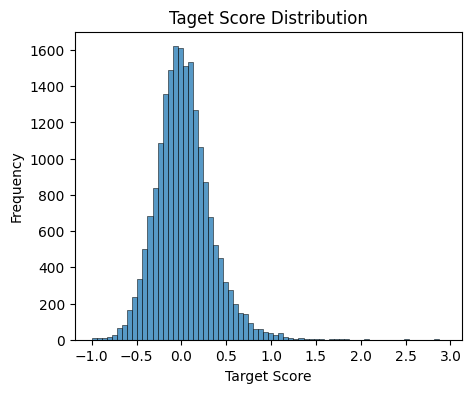

In [27]:
plt.figure(figsize=(5, 4))
sns.histplot(data=df_merged, x="rel_count_diff", bins=70)
plt.title("Taget Score Distribution")
plt.xlabel("Target Score")
plt.ylabel("Frequency")
plt.show()

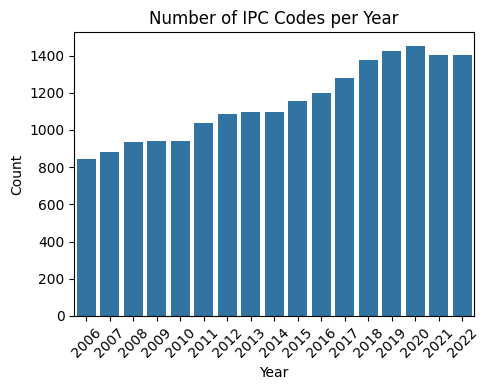

In [28]:
plt.figure(figsize=(5, 4))
sns.countplot(
    data=df_merged, x="pub_year", order=sorted(df_merged["pub_year"].unique())
)
plt.title("Number of IPC Codes per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

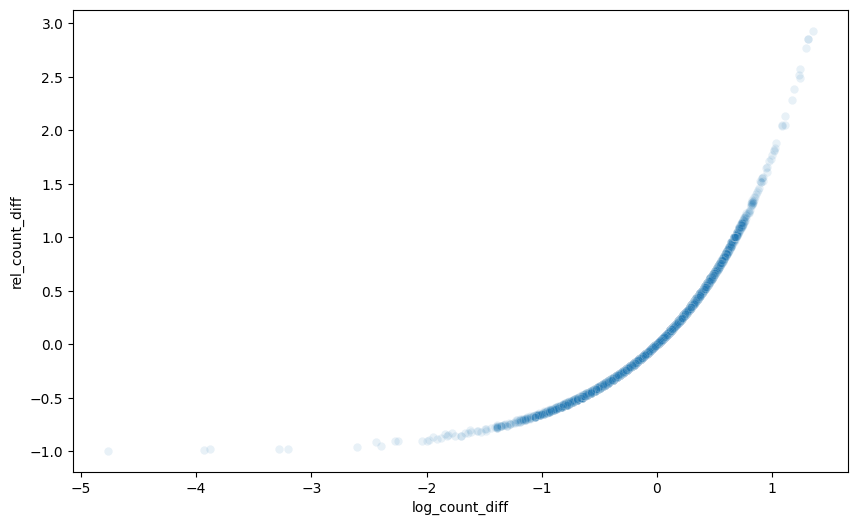

In [24]:
# weighted score and count in x, y
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x="log_count_diff", y="rel_count_diff", alpha=0.1)
# plt.yscale('log')

plt.show()

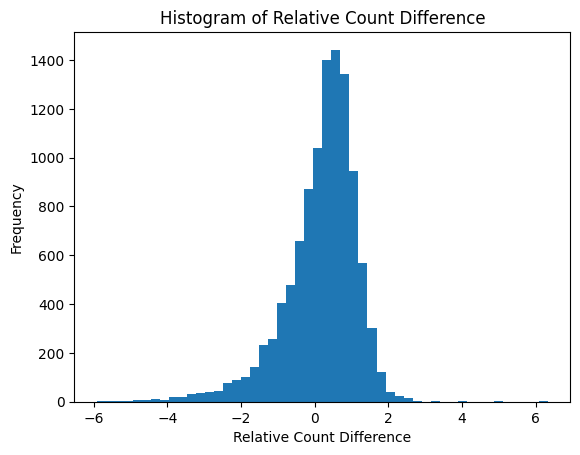

In [ ]:
plt.hist(df_merged["weighted_score"].dropna(), bins=50)
plt.title("Histogram of Relative Count Difference")
plt.xlabel("Relative Count Difference")
plt.ylabel("Frequency")
# plt.yscale('log')
plt.show()

## Get IPC Popularity Data

In [ ]:
df_ipc_counts["pub_year"] = df_ipc_counts["pub_year"].astype(int)

# if IPC code is missing in year, fill with 0
all_ipc_codes = df_ipc_counts["ipc_code"].unique()
all_years = df_ipc_counts["pub_year"].unique()
all_combinations = pd.MultiIndex.from_product(
    [all_ipc_codes, all_years], names=["ipc_code", "pub_year"]
)
df_ipc_counts = (
    df_ipc_counts.set_index(["ipc_code", "pub_year"])
    .reindex(all_combinations, fill_value=0)
    .reset_index()
)

# get list of IPC codes available in all

df_ipc_counts["rank"] = df_ipc_counts.groupby("pub_year")["count"].rank(
    ascending=False, method="min"
)

# filter for years
df_ipc_counts = df_ipc_counts[df_ipc_counts["pub_year"].astype(int) >= 2006]

# calculate top 100, 200, 300 and 500. In the top there should at max be this number of entries.
# since many have the same number of occurences just taking the rank
df_ipc_counts["top_100"] = df_ipc_counts["rank"] <= 100
df_ipc_counts["top_200"] = df_ipc_counts["rank"] <= 200
df_ipc_counts["top_300"] = df_ipc_counts["rank"] <= 300
df_ipc_counts["top_500"] = df_ipc_counts["rank"] <= 500
df_ipc_counts["top_1000"] = df_ipc_counts["rank"] <= 1000

df_ipc_counts.to_parquet("data/ipc_code_yearly_counts.parquet", index=False)

## Exploration

In [ ]:
# load data
df_ipc_counts = pd.read_parquet("data/ipc_code_yearly_counts.parquet")

In [ ]:
# calculate rank for each ipc code per year
df_ipc_counts["rank"] = df_ipc_counts.groupby("pub_year")["count"].rank(
    ascending=False, method="dense"
)

# filter for years
df_ipc_counts = df_ipc_counts[df_ipc_counts["pub_year"].astype(int) >= 2006]

df_ipc_counts["top_100"] = df_ipc_counts["rank"] <= 100
df_ipc_counts["top_200"] = df_ipc_counts["rank"] <= 200
df_ipc_counts["top_500"] = df_ipc_counts["rank"] <= 500

df_ipc_counts.to_parquet("data/ipc_code_yearly_counts.parquet", index=False)

<Axes: xlabel='pub_year', ylabel='count'>

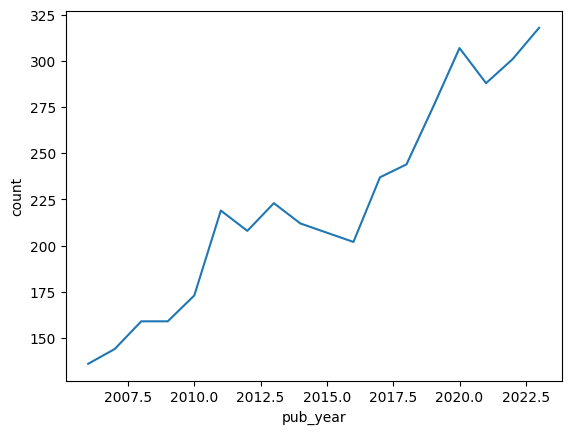

In [ ]:
sns.lineplot(data=df_ipc_counts.query("rank == 100"), x="pub_year", y="count")

(0.0, 500.0)

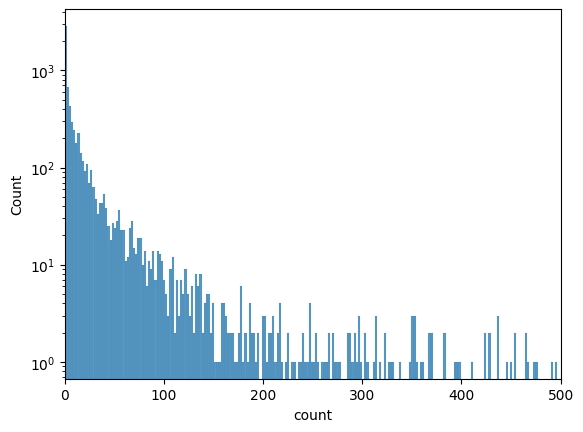

In [ ]:
year = 2021

df_filtered = df_ipc_counts[df_ipc_counts["pub_year"] == year]

sns.histplot(df_filtered["count"], bins=1000)
plt.yscale("log")
# plt.xscale('log')
plt.xlim(0, 500)

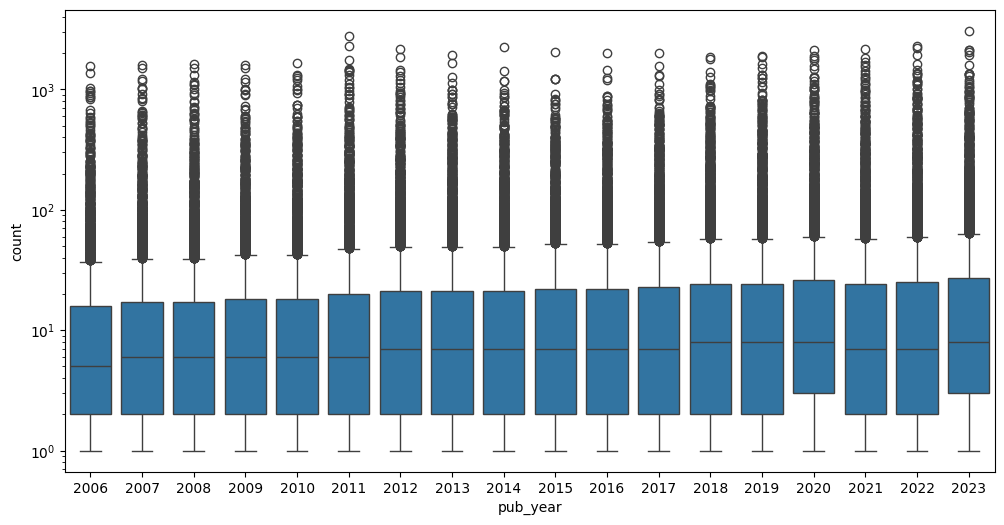

In [ ]:
# create violin plot of counts per ipc code per year
plt.figure(figsize=(12, 6))
sns.boxplot(x="pub_year", y="count", data=df_ipc_counts)
plt.yscale("log")
# limit y axis to 0-1000
# plt.ylim(0, 100)